# MIRT Baseline Router with IRT-Style Routing

This notebook trains and evaluates an offline MIRT (Multidimensional Item Response Theory) router using the IRT routing approach (weighted combination) as a baseline for comparing against the PIKA probe-based router.

- **Data source:** Same cached generations used in `utility_router.ipynb`
- **Models:** Fixed candidate set (5 models)
- **Routing approach:** IRT-style weighted combination: `score = a * performance - (1-a) * cost`
- **Evaluation:** Offline routing with IRT routing objective
- **Comparison:** MIRT (IRT routing) vs Probe Router vs Oracle vs Random

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import os
from collections import Counter
from tqdm import tqdm

# BERT embeddings
from transformers import AutoTokenizer, AutoModel

# Load utility_router helpers
from router_utils import (
    get_gen_str,
    load_model_data,
    get_latest_probe_preds,
    merge_probe_predictions,
    compute_tier_costs,
    route_problems_by_probe_pred,
    oracle_router,
    route_problems_oracle_utility,
    build_comparison_data,
    plot_cost_vs_accuracy,
    plot_probe_histograms,
    dataset_title,
)

/opt/anaconda/envs/pika/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"

## Configuration

Fixed candidate set and dataset selection.

In [3]:
# ── Configuration ──────────────────────────────────────────
# ROUTED_DATASET     = "DigitalLearningGmbH_MATH-lighteval"
ROUTED_DATASET     = "openai_gsm8k" #"openai_gsm8k" #"DigitalLearningGmbH_MATH-lighteval"
PROBE_MODEL_TYPE   = "linear_eoi_probe"
CHOSEN_METRIC      = "majority_vote_is_correct"
DATA_DIR           = "../data"

# Fixed candidate set for MIRT router
MODEL_POOL = [
    "Qwen/Qwen2.5-Math-7B-Instruct",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
    "openai/gpt-oss-20b_low",
    "openai/gpt-oss-20b_medium",
    "openai/gpt-oss-20b_high",
]

print(f"Dataset: {ROUTED_DATASET}")
print(f"Models:")
for m in MODEL_POOL:
    print(f"  • {m}")

# ── Model Card Information ────────────────────────────────────────────
# Rich metadata about each model (with placeholders for missing info)
MODEL_CARDS = {
    "Qwen/Qwen2.5-Math-7B-Instruct": {
        "name": "Qwen2.5-Math-7B-Instruct",
        "description": "Qwen2.5-Math-7B-Instruct. Lower-cost math specialist model trained on mathematical reasoning datasets.",
        "params_b": 7.0,  # 7B parameters
        "training_data": "Math reasoning, instruction-following, majority voting ensemble",
        "capabilities": ["Math reasoning", "Symbolic computation", "Problem solving"],
        "cost_tier": "low",
    },
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B": {
        "name": "DeepSeek-R1-Distill-Qwen-7B",
        "description": "DeepSeek R1-Distill-Qwen-7B. Math specialist with chain-of-thought reasoning capabilities, distilled from larger R1 model.",
        "params_b": 7.0,
        "training_data": "Math reasoning, chain-of-thought, distilled from R1",
        "capabilities": ["Math reasoning", "Chain-of-thought", "Symbolic reasoning"],
        "cost_tier": "medium",
    },
    "openai/gpt-oss-20b_low": {
        "name": "gpt-oss-20b-low",
        "description": "gpt-oss-20b with low reasoning budget. Open-source GPT variant optimized for cost-efficiency.",
        "params_b": 20.0,
        "training_data": "Large scale instruction data, moderate compute budget",
        "capabilities": ["General reasoning", "Problem solving", "Limited depth reasoning"],
        "cost_tier": "low",
    },
    "openai/gpt-oss-20b_medium": {
        "name": "gpt-oss-20b-medium",
        "description": "gpt-oss-20b with medium reasoning budget. Balanced cost and performance.",
        "params_b": 20.0,
        "training_data": "Large scale instruction data, moderate reasoning computation",
        "capabilities": ["General reasoning", "Math problem solving", "Balanced depth"],
        "cost_tier": "medium",
    },
    "openai/gpt-oss-20b_high": {
        "name": "gpt-oss-20b-high",
        "description": "gpt-oss-20b with high reasoning budget. Highest-cost configuration with best accuracy potential.",
        "params_b": 20.0,
        "training_data": "Large scale instruction data, extended reasoning computation",
        "capabilities": ["Advanced reasoning", "Complex math", "Deep analysis"],
        "cost_tier": "high",
    },
}

print("\nModel Cards Loaded:")
for m in MODEL_POOL:
    card = MODEL_CARDS[m]
    print(f"  {card['name']}: {card['params_b']}B params, tier={card['cost_tier']}")

Dataset: openai_gsm8k
Models:
  • Qwen/Qwen2.5-Math-7B-Instruct
  • deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
  • openai/gpt-oss-20b_low
  • openai/gpt-oss-20b_medium
  • openai/gpt-oss-20b_high

Model Cards Loaded:
  Qwen2.5-Math-7B-Instruct: 7.0B params, tier=low
  DeepSeek-R1-Distill-Qwen-7B: 7.0B params, tier=medium
  gpt-oss-20b-low: 20.0B params, tier=low
  gpt-oss-20b-medium: 20.0B params, tier=medium
  gpt-oss-20b-high: 20.0B params, tier=high


## Load Data

Load cached generations the same way as utility_router.ipynb

In [4]:
# ── Load test / train data ─────────────────────────────────
test_dfs, train_dfs = {}, {}

for model in MODEL_POOL:
    t, tr = load_model_data(model, ROUTED_DATASET, DATA_DIR)
    if t is not None:
        test_dfs[model], train_dfs[model] = t, tr
        print(f"✓ {model}: {len(t)} test, {len(tr)} train")

print(f"\n✓ Loaded {len(test_dfs)}/{len(MODEL_POOL)} models")

# ── Extract unique questions (for BERT embedding) ──────────────────────
unique_questions = {}
for model_df in list(train_dfs.values()) + list(test_dfs.values()):
    for idx, row in model_df.iterrows():
        if row['idx'] not in unique_questions:
            unique_questions[row['idx']] = row.get('problem_statement', row.get('question', ''))

question_list = list(unique_questions.keys())
question_texts = [unique_questions[qid] for qid in question_list]
print(f"Unique questions for embedding: {len(question_list)}")

✓ Qwen/Qwen2.5-Math-7B-Instruct: 1319 test, 5979 train
✓ deepseek-ai/DeepSeek-R1-Distill-Qwen-7B: 1319 test, 5979 train
✓ openai/gpt-oss-20b_low: 1319 test, 5979 train
✓ openai/gpt-oss-20b_medium: 1319 test, 5979 train
✓ openai/gpt-oss-20b_high: 1319 test, 5979 train

✓ Loaded 5/5 models
Unique questions for embedding: 6224


## Build BERT Embeddings

Encode questions using BERT [CLS] tokens and model cards into latent representations.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased").to(device)
bert_model.eval()

def embed_texts(texts, tokenizer, model, device, batch_size=32):
    """Embed texts using BERT [CLS] token."""
    embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Embedding texts"):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(batch, return_tensors="pt", truncation=True, 
                               max_length=256, padding=True)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
            # Use [CLS] token (first token of last hidden state)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            embeddings.append(cls_embeddings.cpu().numpy())
    return np.vstack(embeddings)

# Embed questions
print("\nEmbedding questions...")
question_embeddings = embed_texts(question_texts, tokenizer, bert_model, device)
print(f"Question embeddings shape: {question_embeddings.shape}")

# Embed model cards (using model descriptions + capabilities)
print("\nEmbedding model cards...")
model_card_texts = []
for model in MODEL_POOL:
    card = MODEL_CARDS[model]
    # Create rich text description of model
    text = f"{card['description']} Parameters: {card['params_b']}B. Training: {card['training_data']}. Capabilities: {', '.join(card['capabilities'])}."
    model_card_texts.append(text)

model_embeddings = embed_texts(model_card_texts, tokenizer, bert_model, device)
print(f"Model embeddings shape: {model_embeddings.shape}")

# Create mappings
qid_to_idx = {qid: i for i, qid in enumerate(question_list)}
model_to_idx = {m: i for i, m in enumerate(MODEL_POOL)}

print(f"\n✓ BERT embeddings ready: {len(question_list)} questions, {len(MODEL_POOL)} models")

Device: cuda

Embedding questions...


Embedding texts: 100%|██████████| 195/195 [00:01<00:00, 140.02it/s]


Question embeddings shape: (6224, 768)

Embedding model cards...


Embedding texts: 100%|██████████| 1/1 [00:00<00:00, 93.98it/s]

Model embeddings shape: (5, 768)

✓ BERT embeddings ready: 6224 questions, 5 models


## Prepare Data for MIRT

Merge all models into a single table with question × model × (correctness, cost) tuples.

In [6]:
# Merge all train data
all_train = []
for model, df in train_dfs.items():
    df_copy = df.copy()
    df_copy['llm'] = model
    all_train.append(df_copy)

train_merged = pd.concat(all_train, ignore_index=True)

# Add numeric indices using BERT embedding mappings
train_merged['q_idx_numeric'] = train_merged['idx'].map(lambda qid: qid_to_idx.get(qid, -1))
train_merged['m_idx_numeric'] = train_merged['llm'].map(lambda m: model_to_idx.get(m, -1))

# Filter out unmapped rows
train_merged = train_merged[(train_merged['q_idx_numeric'] >= 0) & (train_merged['m_idx_numeric'] >= 0)]

print(f"Train merged: {len(train_merged)} rows")

# Merge all test data
all_test = []
for model, df in test_dfs.items():
    df_copy = df.copy()
    df_copy['llm'] = model
    all_test.append(df_copy)

test_merged = pd.concat(all_test, ignore_index=True)

# Add numeric indices using BERT embedding mappings
test_merged['q_idx_numeric'] = test_merged['idx'].map(lambda qid: qid_to_idx.get(qid, -1))
test_merged['m_idx_numeric'] = test_merged['llm'].map(lambda m: model_to_idx.get(m, -1))

# Filter out unmapped rows
test_merged = test_merged[(test_merged['q_idx_numeric'] >= 0) & (test_merged['m_idx_numeric'] >= 0)]

print(f"Test merged: {len(test_merged)} rows")

# Show sample
print("\nSample:")
print(train_merged.head())

Train merged: 29895 rows
Test merged: 6595 rows

Sample:
    idx                                            problem  \
0  1297  In Professor Plum's biology class there are 40...   
1   576  Diane bought twenty more apples than Cecile. I...   
2  5462  Ann can skate 6 miles an hour. Her friend Glen...   
3  4336  Running for 2 hours, Jonah burnt 30 calories e...   
4  7105  The city of Richmond has 1000 more people than...   

                                    formatted_prompt ground_truth  \
0  <|im_start|>system\nPlease reason step by step...            8   
1  <|im_start|>system\nPlease reason step by step...           50   
2  <|im_start|>system\nPlease reason step by step...           42   
3  <|im_start|>system\nPlease reason step by step...           90   
4  <|im_start|>system\nPlease reason step by step...          500   

                                 generated_solutions  total_input_tokens  \
0  [{'input_cost_usd_once': 1.84e-05, 'input_toke...                  92   
1  

## MIRT Model Definition

2PL (two-parameter logistic) multidimensional IRT model.

In [7]:
class MIRTModel(nn.Module):
    """Multidimensional 2PL IRT model with BERT embedding initialization."""
    def __init__(self, n_questions, n_models, latent_dim=25, 
                 question_embeddings=None, model_embeddings=None):
        super().__init__()
        
        # Initialize from BERT embeddings or random
        if question_embeddings is not None:
            # Project BERT embeddings (768-dim) down to latent_dim
            theta_init = torch.from_numpy(question_embeddings).float()
            if theta_init.shape[1] != latent_dim:
                # If BERT embedding dim != latent_dim, project
                proj = nn.Linear(theta_init.shape[1], latent_dim)
                theta_init = proj(theta_init)
            self.theta = nn.Parameter(theta_init)
        else:
            self.theta = nn.Parameter(torch.randn(n_questions, latent_dim) * 0.01)
        
        if model_embeddings is not None:
            # Project BERT embeddings for models
            beta_init = torch.from_numpy(model_embeddings).float()
            if beta_init.shape[1] != latent_dim:
                proj = nn.Linear(beta_init.shape[1], latent_dim)
                beta_init = proj(beta_init)
            self.beta = nn.Parameter(beta_init)
        else:
            self.beta = nn.Parameter(torch.randn(n_models, latent_dim) * 0.01)
        
        self.bias = nn.Parameter(torch.zeros(n_models))

    def forward(self, q_idx, m_idx):
        # 2PL: p = sigmoid(theta_q · beta_m + bias_m)
        dot = (self.theta[q_idx] * self.beta[m_idx]).sum(dim=1) + self.bias[m_idx]
        return torch.sigmoid(dot)

## Train MIRT

Train on the merged train set.

In [8]:
# Hyperparams
latent_dim = 25  # Project BERT 768-dim down to this
lr = 0.002
batch_size = 512
epochs = 100
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

# Model with BERT embedding initialization
n_questions = len(question_list)
n_models = len(MODEL_POOL)

print(f"\nInitializing MIRT with BERT embeddings:")
print(f"  Questions: {n_questions} (BERT 768-dim)")
print(f"  Models: {n_models} (BERT 768-dim, from model cards)")
print(f"  Projecting to latent_dim={latent_dim}")

mirt_model = MIRTModel(
    n_questions, n_models, latent_dim,
    question_embeddings=question_embeddings,
    model_embeddings=model_embeddings
).to(device)

optimizer = optim.Adam(mirt_model.parameters(), lr=lr)
loss_fn = nn.BCELoss()

# Prepare data
q_idx = train_merged['q_idx_numeric'].values.astype(np.int64)
m_idx = train_merged['m_idx_numeric'].values.astype(np.int64)
y = train_merged['majority_vote_is_correct'].values.astype(np.float32)

print(f"\nTraining MIRT:")
print(f"  Data: {len(y)} samples, {n_questions} questions, {n_models} models")
print(f"  Latent dim: {latent_dim} (projected from BERT 768-dim)")
print(f"  Learning rate: {lr}, batch size: {batch_size}, epochs: {epochs}")

# Training loop
mirt_model.train()
for epoch in range(epochs):
    perm = np.random.permutation(len(y))
    epoch_loss = 0
    n_batches = 0
    
    for i in range(0, len(y), batch_size):
        idx = perm[i:i+batch_size]
        q = torch.tensor(q_idx[idx], dtype=torch.long).to(device)
        m = torch.tensor(m_idx[idx], dtype=torch.long).to(device)
        target = torch.tensor(y[idx], dtype=torch.float32).to(device)
        
        pred = mirt_model(q, m)
        loss = loss_fn(pred, target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        avg_loss = epoch_loss / n_batches
        print(f"  Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f}")

print("\n✓ MIRT training complete (initialized from BERT embeddings, fine-tuned on training data)")


Initializing MIRT with BERT embeddings:
  Questions: 6224 (BERT 768-dim)
  Models: 5 (BERT 768-dim, from model cards)
  Projecting to latent_dim=25

Training MIRT:
  Data: 29895 samples, 6224 questions, 5 models
  Latent dim: 25 (projected from BERT 768-dim)
  Learning rate: 0.002, batch size: 512, epochs: 100


  Epoch   1/100 | Loss: 0.3901
  Epoch  10/100 | Loss: 0.0771
  Epoch  20/100 | Loss: 0.0393
  Epoch  30/100 | Loss: 0.0190
  Epoch  40/100 | Loss: 0.0085
  Epoch  50/100 | Loss: 0.0036
  Epoch  60/100 | Loss: 0.0016
  Epoch  70/100 | Loss: 0.0009
  Epoch  80/100 | Loss: 0.0005
  Epoch  90/100 | Loss: 0.0003
  Epoch 100/100 | Loss: 0.0002

✓ MIRT training complete (initialized from BERT embeddings, fine-tuned on training data)


## Evaluate MIRT on Test Set

Score all models for each test question and route using utility objective.

In [9]:
# Compute normalized costs from train set
avg_cost = train_merged.groupby('llm')['total_output_cost_usd'].mean().to_dict()
cost_min, cost_max = min(avg_cost.values()), max(avg_cost.values())
norm_cost = {m: (c - cost_min) / (cost_max - cost_min) if cost_max > cost_min else 0 for m, c in avg_cost.items()}

print("Normalized costs:")
for m, c in sorted(norm_cost.items(), key=lambda x: x[1]):
    print(f"  {m.split('/')[-1]:30s} {c:.4f}")

# Define lambda_val for probe router compatibility
lambda_val = 0.2

Normalized costs:
  gpt-oss-20b_low                0.0000
  Qwen2.5-Math-7B-Instruct       0.0171
  gpt-oss-20b_medium             0.2452
  DeepSeek-R1-Distill-Qwen-7B    0.5130
  gpt-oss-20b_high               1.0000


In [10]:
# Route using IRT-style weighted combination: score = a * prob - (1-a) * cost
# where a=0.8 means 80% weight on performance, 20% weight on cost
a_val = 0.8
b_val = -(1 - a_val)  # b = -0.2
mirt_model.eval()

mirt_results = []
with torch.no_grad():
    for (qid, q_group) in test_merged.groupby('idx'):
        cands = []
        for _, row in q_group.iterrows():
            q_numeric = int(row['q_idx_numeric'])
            m_numeric = int(row['m_idx_numeric'])
            
            q_tensor = torch.tensor([q_numeric], dtype=torch.long).to(device)
            m_tensor = torch.tensor([m_numeric], dtype=torch.long).to(device)
            prob = mirt_model(q_tensor, m_tensor).item()
            
            # IRT-style scoring: score = a * performance - (1-a) * cost
            cost_llm = row['total_output_cost_usd'] * 1e5  # Scale cost like IRT router
            score = a_val * prob + b_val * cost_llm
            
            cands.append({
                'llm': row['llm'],
                'pred_p': prob,
                'cost_scaled': cost_llm,
                'score': score,
                'realized_correct': row['majority_vote_is_correct'],
                'realized_cost': row['total_output_cost_usd'],
            })
        
        chosen = max(cands, key=lambda x: x['score'])
        mirt_results.append({
            'qid': qid,
            'chosen_llm': chosen['llm'],
            'chosen_predicted_p': chosen['pred_p'],
            'chosen_cost_scaled': chosen['cost_scaled'],
            'chosen_score': chosen['score'],
            'realized_correct': chosen['realized_correct'],
            'realized_cost': chosen['realized_cost'],
        })

mirt_results_df = pd.DataFrame(mirt_results)

## Compute Metrics

Compare MIRT router against oracle, random, and single-model baselines.

In [11]:
# MIRT results
mirt_acc = mirt_results_df['realized_correct'].mean()
mirt_cost = mirt_results_df['realized_cost'].sum()
mirt_freq = dict(Counter(mirt_results_df['chosen_llm']))

# Oracle
oracle = test_merged.groupby('idx').apply(lambda g: g.loc[g['majority_vote_is_correct'].idxmax()])
oracle_acc = oracle['majority_vote_is_correct'].mean()
oracle_cost = oracle['total_output_cost_usd'].sum()

# Random
rng = np.random.RandomState(42)
random_choices = test_merged.groupby('idx').apply(lambda g: g.sample(1, random_state=rng))
random_acc = random_choices['majority_vote_is_correct'].mean()
random_cost = random_choices['total_output_cost_usd'].sum()

# Single models
single_model_perf = []
for m in MODEL_POOL:
    if m in test_dfs:
        df = test_dfs[m]
        acc = df['majority_vote_is_correct'].mean()
        cost = df['total_output_cost_usd'].sum()
        single_model_perf.append({'model': m, 'accuracy': acc, 'cost': cost})
single_models_df = pd.DataFrame(single_model_perf)

# Summary
print("\n" + "="*70)
print("MIRT ROUTER PERFORMANCE")
print("="*70)
print(f"Accuracy:       {mirt_acc:.4f}")
print(f"Total cost:     ${mirt_cost:.6f}")
print(f"Selection freq: {mirt_freq}")
print()
print("Baselines:")
print(f"  Oracle:       acc={oracle_acc:.4f}, cost=${oracle_cost:.6f}, gap={oracle_acc-mirt_acc:.4f}")
print(f"  Random:       acc={random_acc:.4f}, cost=${random_cost:.6f}")
print()
print("Single-model baselines:")
for _, row in single_models_df.iterrows():
    print(f"  {row['model'].split('/')[-1]:30s} acc={row['accuracy']:.4f}, cost=${row['cost']:.6f}")

/tmp/ipykernel_624868/610034042.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  oracle = test_merged.groupby('idx').apply(lambda g: g.loc[g['majority_vote_is_correct'].idxmax()])



MIRT ROUTER PERFORMANCE
Accuracy:       0.9204
Total cost:     $0.349906
Selection freq: {'openai/gpt-oss-20b_low': 892, 'Qwen/Qwen2.5-Math-7B-Instruct': 422, 'openai/gpt-oss-20b_medium': 4, 'deepseek-ai/DeepSeek-R1-Distill-Qwen-7B': 1}

Baselines:
  Oracle:       acc=0.9780, cost=$0.462399, gap=0.0576
  Random:       acc=0.9196, cost=$0.980868

Single-model baselines:
  Qwen2.5-Math-7B-Instruct       acc=0.9477, cost=$0.429319
  DeepSeek-R1-Distill-Qwen-7B    acc=0.8810, cost=$1.383164
  gpt-oss-20b_low                acc=0.8999, cost=$0.386550
  gpt-oss-20b_medium             acc=0.9333, cost=$0.823352
  gpt-oss-20b_high               acc=0.9439, cost=$2.137163


/tmp/ipykernel_624868/610034042.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  random_choices = test_merged.groupby('idx').apply(lambda g: g.sample(1, random_state=rng))


## Compare MIRT vs Probe Router

Load probe predictions and compare routing strategies.

In [12]:
# Load probe predictions (same as utility_router.ipynb)
test_dfs_with_probes = {}

for model in MODEL_POOL:
    gen_str = get_gen_str(model)
    preds = get_latest_probe_preds(
        ROUTED_DATASET, model, gen_str,
        probe_model_type=PROBE_MODEL_TYPE,
        chosen_metric=CHOSEN_METRIC,
        data_dir=DATA_DIR,
    )
    if preds is not None:
        test_dfs_with_probes[model] = merge_probe_predictions(test_dfs[model], preds)
        pp = test_dfs_with_probes[model]["probe_pred"]
        print(f"  ✓ {model}: {len(pp)} rows, pred ∈ [{pp.min():.4f}, {pp.max():.4f}]")

print(f"\n✓ {len(test_dfs_with_probes)} models loaded with probe predictions")

✓ Loading probes for Qwen/Qwen2.5-Math-7B-Instruct from: 20260217_035525
  ✓ Qwen/Qwen2.5-Math-7B-Instruct: 1319 rows, pred ∈ [0.4511, 0.9964]
✓ Loading probes for deepseek-ai/DeepSeek-R1-Distill-Qwen-7B from: 20260217_034600
  ✓ deepseek-ai/DeepSeek-R1-Distill-Qwen-7B: 1319 rows, pred ∈ [0.5940, 0.9789]
✓ Loading probes for openai/gpt-oss-20b_low from: 20260204_043813
  ✓ openai/gpt-oss-20b_low: 1319 rows, pred ∈ [0.2055, 0.9962]
✓ Loading probes for openai/gpt-oss-20b_medium from: 20260203_233434
  ✓ openai/gpt-oss-20b_medium: 1319 rows, pred ∈ [0.0001, 1.0000]
✓ Loading probes for openai/gpt-oss-20b_high from: 20260204_004114
  ✓ openai/gpt-oss-20b_high: 1319 rows, pred ∈ [0.5361, 0.9938]

✓ 5 models loaded with probe predictions


In [13]:
# Compute tier costs
tier_costs, tier_costs_normalized = compute_tier_costs(MODEL_POOL, train_dfs)

print("Tier costs (avg total_output_cost_usd):")
for i, m in enumerate(MODEL_POOL, 1):
    print(f"  {i}. {m.split('/')[-1]:30s}  ${tier_costs[m]:.6f}  →  norm {tier_costs_normalized[m]:.4f}")

Tier costs (avg total_output_cost_usd):
  1. Qwen2.5-Math-7B-Instruct        $0.000316  →  norm 0.0171
  2. DeepSeek-R1-Distill-Qwen-7B     $0.000991  →  norm 0.5130
  3. gpt-oss-20b_low                 $0.000293  →  norm 0.0000
  4. gpt-oss-20b_medium              $0.000627  →  norm 0.2452
  5. gpt-oss-20b_high                $0.001655  →  norm 1.0000


In [14]:
# Probe-based router
routed_df_probe = route_problems_by_probe_pred(
    test_dfs_with_probes, MODEL_POOL, CHOSEN_METRIC,
    strategy="max_utility", value=lambda_val,
    tier_costs_dict=tier_costs_normalized,
    utility_variant=f"og_{lambda_val:.6f}",
)

probe_acc = routed_df_probe[CHOSEN_METRIC].mean()
probe_cost = routed_df_probe['total_output_cost_usd'].sum()

print(f"Probe Router (λ={lambda_val}):")
print(f"  Accuracy: {probe_acc:.4f}")
print(f"  Cost:     ${probe_cost:.6f}")

Probe Router (λ=0.2):
  Accuracy: 0.9439
  Cost:     $0.561659


In [15]:
print("Columns in routed_df_probe:")
print([c for c in routed_df_probe.columns if 'model' in c.lower() or 'llm' in c.lower() or 'chosen' in c.lower()])
print("\nFirst few rows:")
print(routed_df_probe.head(3))

Columns in routed_df_probe:
['model_name']

First few rows:
   idx                 model_name  majority_vote_is_correct  probe_pred_class  \
0    0     openai/gpt-oss-20b_low                       1.0          0.986816   
1    1     openai/gpt-oss-20b_low                       1.0          0.964281   
2    2  openai/gpt-oss-20b_medium                       1.0          0.882326   

   total_output_cost_usd   utility  
0               0.000195  0.986816  
1               0.000151  0.964281  
2               0.001300  0.833290  


## Comparison Summary Table

In [16]:
comparison_results = [
    {'Strategy': 'MIRT Router (λ=0.2)', 'Accuracy': mirt_acc, 'Cost': mirt_cost, 'Type': 'MIRT'},
    {'Strategy': 'Probe Router (λ=0.2)', 'Accuracy': probe_acc, 'Cost': probe_cost, 'Type': 'Probe'},
    {'Strategy': 'Oracle', 'Accuracy': oracle_acc, 'Cost': oracle_cost, 'Type': 'Oracle'},
    {'Strategy': 'Random', 'Accuracy': random_acc, 'Cost': random_cost, 'Type': 'Random'},
]

# Add single models
for _, row in single_models_df.iterrows():
    comparison_results.append({
        'Strategy': f'Always {row["model"].split("/")[-1]}',
        'Accuracy': row['accuracy'],
        'Cost': row['cost'],
        'Type': 'Single'
    })

comparison_df = pd.DataFrame(comparison_results).sort_values('Cost')
print(comparison_df.to_string(index=False))

print(f"\nGap to Oracle: {oracle_acc - mirt_acc:.4f}")

                          Strategy  Accuracy     Cost   Type
               MIRT Router (λ=0.2)  0.920394 0.349906   MIRT
            Always gpt-oss-20b_low  0.899924 0.386550 Single
   Always Qwen2.5-Math-7B-Instruct  0.947688 0.429319 Single
                            Oracle  0.978014 0.462399 Oracle
              Probe Router (λ=0.2)  0.943897 0.561659  Probe
         Always gpt-oss-20b_medium  0.933283 0.823352 Single
                            Random  0.919636 0.980868 Random
Always DeepSeek-R1-Distill-Qwen-7B  0.880970 1.383164 Single
           Always gpt-oss-20b_high  0.943897 2.137163 Single

Gap to Oracle: 0.0576


## Pareto Plot

Visualize accuracy vs cost tradeoff.

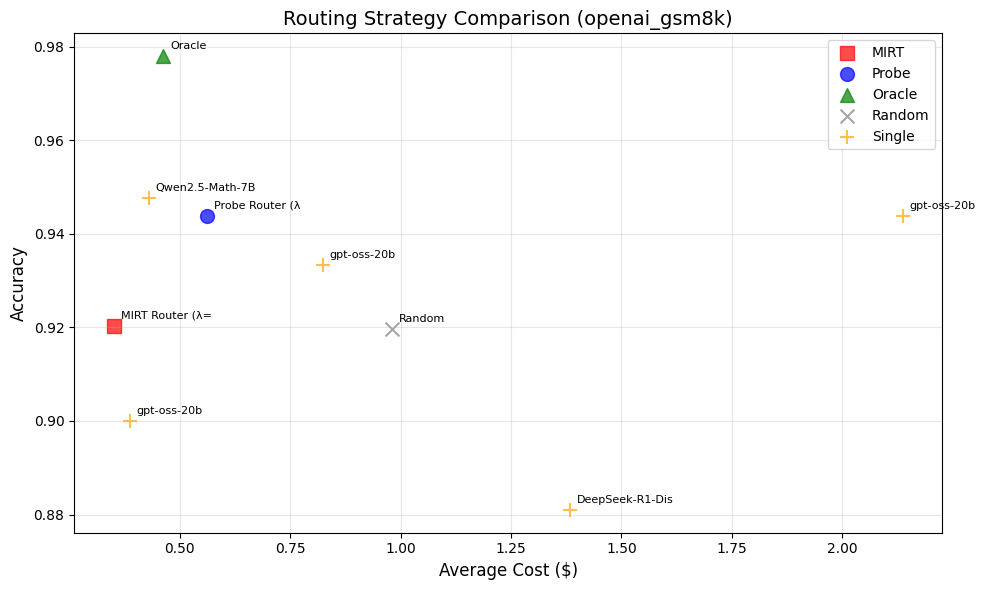

✓ Pareto plot saved to figs/mirt_vs_probe_pareto.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot strategies
for strategy_type, color, marker in [
    ('MIRT', 'red', 's'),
    ('Probe', 'blue', 'o'),
    ('Oracle', 'green', '^'),
    ('Random', 'gray', 'x'),
    ('Single', 'orange', '+')
]:
    subset = comparison_df[comparison_df['Type'] == strategy_type]
    ax.scatter(subset['Cost'], subset['Accuracy'], 
               label=strategy_type, color=color, marker=marker, s=100, alpha=0.7)
    
    # Label each point
    for _, row in subset.iterrows():
        label = row['Strategy'].replace('Always ', '').split('_')[0][:15]
        ax.annotate(label, (row['Cost'], row['Accuracy']), 
                   xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel('Average Cost ($)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(f'Routing Strategy Comparison ({ROUTED_DATASET})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figs/mirt_vs_probe_pareto.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Pareto plot saved to figs/mirt_vs_probe_pareto.png")

## Performance Weight Sweep for MIRT Pareto Frontier

Evaluate MIRT router across different performance-cost tradeoff parameters (a) to generate full Pareto frontier using IRT-style routing.


In [18]:
# Performance weight sweep for MIRT Pareto curve using IRT-style routing
# a = performance weight (0 = pure cost optimization, 1 = pure performance optimization)
a_values = np.linspace(0, 1.0, 21)  # 0 to 1.0 in steps of 0.05
mirt_pareto = []

mirt_model.eval()
with torch.no_grad():
    for a in a_values:
        b = -(1 - a)  # Cost weight
        mirt_results_sweep = []
        for (qid, q_group) in test_merged.groupby('idx'):
            cands = []
            for _, row in q_group.iterrows():
                q_numeric = int(row['q_idx_numeric'])
                m_numeric = int(row['m_idx_numeric'])
                
                q_tensor = torch.tensor([q_numeric], dtype=torch.long).to(device)
                m_tensor = torch.tensor([m_numeric], dtype=torch.long).to(device)
                prob = mirt_model(q_tensor, m_tensor).item()
                
                # IRT-style scoring
                cost_llm = row['total_output_cost_usd'] * 1e5
                score = a * prob + b * cost_llm
                
                cands.append({
                    'realized_correct': row['majority_vote_is_correct'],
                    'realized_cost': row['total_output_cost_usd'],
                    'score': score,
                })
            
            chosen = max(cands, key=lambda x: x['score'])
            mirt_results_sweep.append(chosen)
        
        acc = np.mean([r['realized_correct'] for r in mirt_results_sweep])
        cost = np.sum([r['realized_cost'] for r in mirt_results_sweep])
        mirt_pareto.append({'a': a, 'accuracy': acc, 'cost': cost})

mirt_pareto_df = pd.DataFrame(mirt_pareto)
print(f"Performance weight sweep complete: {len(mirt_pareto)} points")
print(mirt_pareto_df.to_string())

Performance weight sweep complete: 21 points
       a  accuracy      cost
0   0.00  0.919636  0.349545
1   0.05  0.919636  0.349545
2   0.10  0.919636  0.349545
3   0.15  0.919636  0.349545
4   0.20  0.919636  0.349545
5   0.25  0.919636  0.349548
6   0.30  0.919636  0.349548
7   0.35  0.919636  0.349548
8   0.40  0.919636  0.349554
9   0.45  0.919636  0.349554
10  0.50  0.919636  0.349554
11  0.55  0.919636  0.349567
12  0.60  0.919636  0.349567
13  0.65  0.919636  0.349567
14  0.70  0.919636  0.349607
15  0.75  0.919636  0.349741
16  0.80  0.920394  0.349906
17  0.85  0.920394  0.350234
18  0.90  0.920394  0.351589
19  0.95  0.921911  0.354348
20  1.00  0.940864  2.012962


## Full Pareto Frontier Visualization (IRT Routing)

Plot MIRT sweep (IRT routing) alongside probe router and baseline strategies.


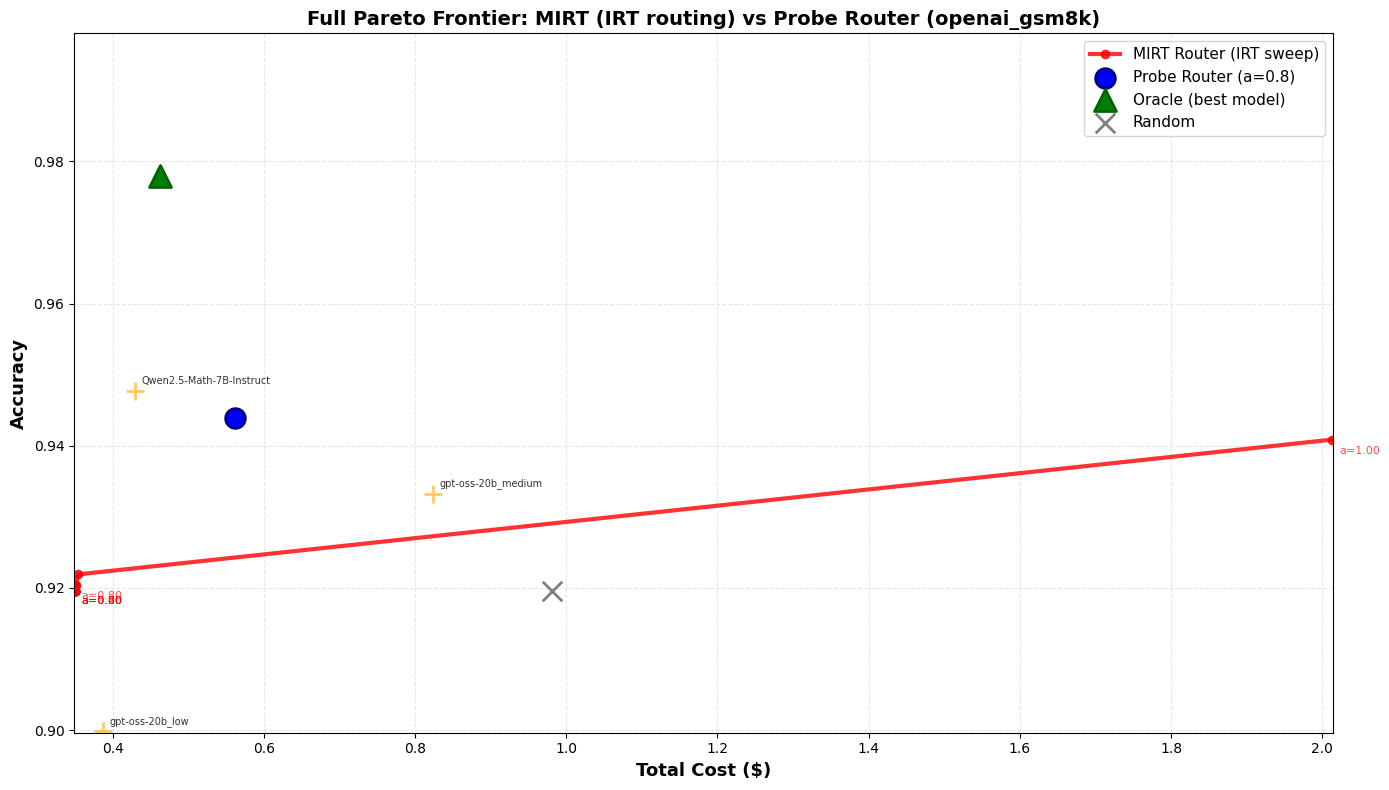

✓ Full Pareto frontier (IRT routing) saved


In [19]:
fig, ax = plt.subplots(figsize=(14, 8))

# MIRT Pareto frontier (curve) - IRT routing
ax.plot(mirt_pareto_df['cost'], mirt_pareto_df['accuracy'], 
        'r-', linewidth=3, label='MIRT Router (IRT sweep)', marker='o', markersize=6, alpha=0.8)

# Probe Router
ax.scatter([probe_cost], [probe_acc], 
           s=200, c='blue', marker='o', label=f'Probe Router (a=0.8)', edgecolor='navy', linewidth=2, zorder=10)

# Oracle, Random, Single models
ax.scatter([oracle_cost], [oracle_acc], 
           s=250, c='green', marker='^', label='Oracle (best model)', edgecolor='darkgreen', linewidth=2, zorder=10)
ax.scatter([random_cost], [random_acc], 
           s=200, c='gray', marker='x', label='Random', linewidth=2, zorder=10)

# Single model baselines
for _, row in single_models_df.iterrows():
    model_short = row['model'].split('/')[-1]
    ax.scatter([row['cost']], [row['accuracy']], 
              s=150, c='orange', marker='+', alpha=0.6, linewidth=2)
    ax.annotate(model_short, (row['cost'], row['accuracy']), 
               xytext=(5, 5), textcoords='offset points', fontsize=7, alpha=0.8)

# Annotate MIRT sweep with performance weight (a) values
for idx, row in mirt_pareto_df.iterrows():
    if idx % 4 == 0 or idx == 0 or idx == len(mirt_pareto_df) - 1:  # Label every 4th point
        ax.annotate(f"a={row['a']:.2f}", 
                   (row['cost'], row['accuracy']),
                   xytext=(5, -10), textcoords='offset points', 
                   fontsize=8, color='red', alpha=0.7)

ax.set_xlabel('Total Cost ($)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title(f'Full Pareto Frontier: MIRT (IRT routing) vs Probe Router ({ROUTED_DATASET})', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(min(mirt_pareto_df['cost'].min(), probe_cost) - 0.0005, 
           max(mirt_pareto_df['cost'].max(), probe_cost) + 0.001)
ax.set_ylim(random_acc - 0.02, oracle_acc + 0.02)

plt.tight_layout()
plt.savefig('../figs/mirt_og_full_pareto_frontier.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Full Pareto frontier (IRT routing) saved")

## Comprehensive Results Table

Detailed comparison across all strategies and lambda values.


In [20]:
# Build comprehensive results table
results_table = []

# Add MIRT sweep results
for _, row in mirt_pareto_df.iterrows():
    gap_to_oracle = oracle_acc - row['accuracy']
    results_table.append({
        'Strategy': 'MIRT Router',
        'a (Perf Weight)': f"{row['a']:.2f}",
        'Accuracy': f"{row['accuracy']:.4f}",
        'Cost': f"${row['cost']:.6f}",
        'Gap to Oracle': f"{gap_to_oracle:.4f}",
        'Type': 'MIRT'
    })

# Add Probe Router
results_table.append({
    'Strategy': 'Probe Router',
    'Lambda': f"{lambda_val:.2f}",
    'Accuracy': f"{probe_acc:.4f}",
    'Cost': f"${probe_cost:.6f}",
    'Gap to Oracle': f"{oracle_acc - probe_acc:.4f}",
    'Type': 'Probe'
})

# Add Oracle
results_table.append({
    'Strategy': 'Oracle',
    'Lambda': '—',
    'Accuracy': f"{oracle_acc:.4f}",
    'Cost': f"${oracle_cost:.6f}",
    'Gap to Oracle': f"{0:.4f}",
    'Type': 'Oracle'
})

# Add Random
results_table.append({
    'Strategy': 'Random',
    'Lambda': '—',
    'Accuracy': f"{random_acc:.4f}",
    'Cost': f"${random_cost:.6f}",
    'Gap to Oracle': f"{oracle_acc - random_acc:.4f}",
    'Type': 'Random'
})

# Add single models
for _, row in single_models_df.iterrows():
    model_short = row['model'].split('/')[-1]
    results_table.append({
        'Strategy': f'Always {model_short}',
        'Lambda': '—',
        'Accuracy': f"{row['accuracy']:.4f}",
        'Cost': f"${row['cost']:.6f}",
        'Gap to Oracle': f"{oracle_acc - row['accuracy']:.4f}",
        'Type': 'Single'
    })

results_df = pd.DataFrame(results_table)

print("\n" + "="*100)
print("COMPREHENSIVE RESULTS TABLE")
print("="*100)
print(results_df.to_string(index=False))

# Summary statistics
print("\n" + "="*100)
print("SUMMARY STATISTICS")
print("="*100)
print(f"\nMIRT Router Summary (λ=0.2):")
print(f"  Accuracy vs Probe Router: {((mirt_acc / probe_acc - 1) * 100):+.2f}%")
print(f"  Cost vs Probe Router:      {((mirt_cost / probe_cost - 1) * 100):+.2f}%")
print(f"  Gap to Oracle:             {oracle_acc - mirt_acc:.4f}")

print(f"\nBest MIRT Operating Point (max accuracy):")
best_mirt_idx = mirt_pareto_df['accuracy'].idxmax()
best_mirt = mirt_pareto_df.iloc[best_mirt_idx]
print(f"  a={best_mirt['a']:.2f}: acc={best_mirt['accuracy']:.4f}, cost=${best_mirt['cost']:.6f}")

print(f"\nMost Cost-Efficient MIRT (min cost):")
min_cost_idx = mirt_pareto_df['cost'].idxmin()
min_cost_mirt = mirt_pareto_df.iloc[min_cost_idx]
print(f"  a={min_cost_mirt['a']:.2f}: acc={min_cost_mirt['accuracy']:.4f}, cost=${min_cost_mirt['cost']:.6f}")


COMPREHENSIVE RESULTS TABLE
                          Strategy a (Perf Weight) Accuracy      Cost Gap to Oracle   Type Lambda
                       MIRT Router            0.00   0.9196 $0.349545        0.0584   MIRT    NaN
                       MIRT Router            0.05   0.9196 $0.349545        0.0584   MIRT    NaN
                       MIRT Router            0.10   0.9196 $0.349545        0.0584   MIRT    NaN
                       MIRT Router            0.15   0.9196 $0.349545        0.0584   MIRT    NaN
                       MIRT Router            0.20   0.9196 $0.349545        0.0584   MIRT    NaN
                       MIRT Router            0.25   0.9196 $0.349548        0.0584   MIRT    NaN
                       MIRT Router            0.30   0.9196 $0.349548        0.0584   MIRT    NaN
                       MIRT Router            0.35   0.9196 $0.349548        0.0584   MIRT    NaN
                       MIRT Router            0.40   0.9196 $0.349554        0.0584   MIR

## Model Selection Pattern Over Performance Weight

Show how MIRT preferentially selects models as the performance weight (a) changes.


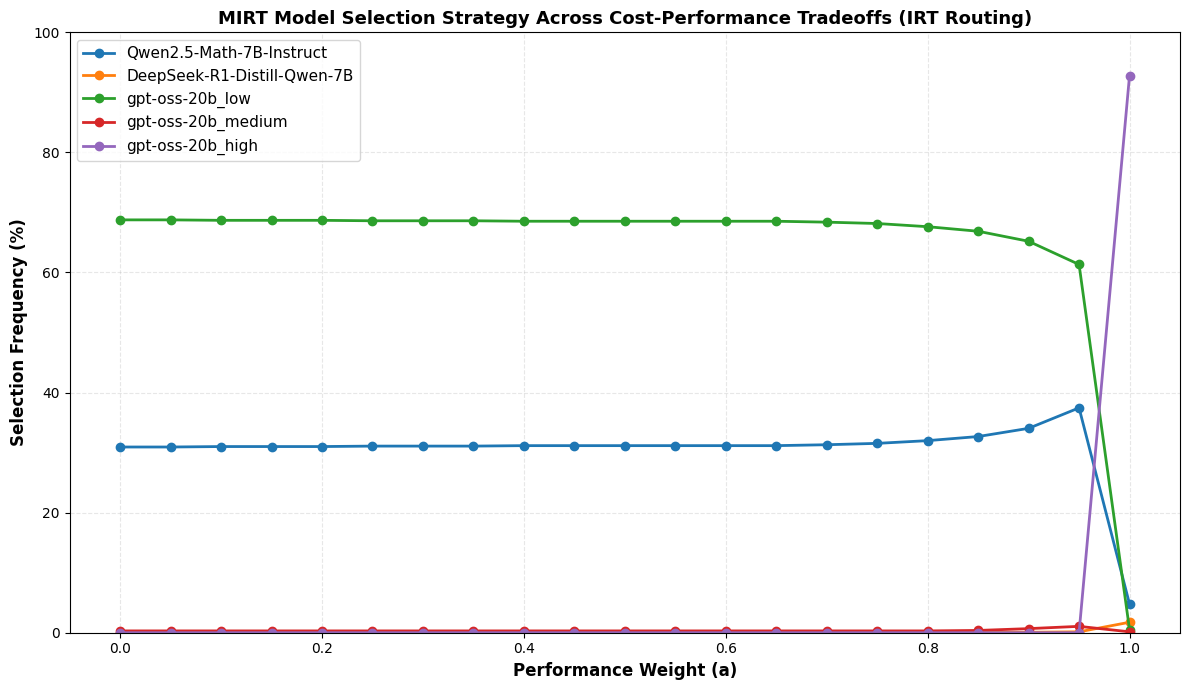

✓ Model selection pattern (IRT routing) saved

Model Selection by Performance Weight (a):
   a Qwen2.5-Math-7B-Instruct DeepSeek-R1-Distill-Qwen-7B gpt-oss-20b_low gpt-oss-20b_medium gpt-oss-20b_high
0.00                    30.9%                        0.0%           68.8%               0.3%             0.0%
0.05                    30.9%                        0.0%           68.8%               0.3%             0.0%
0.10                    31.0%                        0.0%           68.7%               0.3%             0.0%
0.15                    31.0%                        0.0%           68.7%               0.3%             0.0%
0.20                    31.0%                        0.0%           68.7%               0.3%             0.0%
0.25                    31.1%                        0.0%           68.6%               0.3%             0.0%
0.30                    31.1%                        0.0%           68.6%               0.3%             0.0%
0.35                    31.1% 

In [21]:
# Track model selection across performance weight (a) values using IRT-style routing
model_selection_by_a = {m: [] for m in MODEL_POOL}

mirt_model.eval()
with torch.no_grad():
    for a in a_values:
        b = -(1 - a)
        selections = Counter()
        for (qid, q_group) in test_merged.groupby('idx'):
            cands = []
            for _, row in q_group.iterrows():
                q_numeric = int(row['q_idx_numeric'])
                m_numeric = int(row['m_idx_numeric'])
                
                q_tensor = torch.tensor([q_numeric], dtype=torch.long).to(device)
                m_tensor = torch.tensor([m_numeric], dtype=torch.long).to(device)
                prob = mirt_model(q_tensor, m_tensor).item()
                
                # IRT-style scoring
                cost_llm = row['total_output_cost_usd'] * 1e5
                score = a * prob + b * cost_llm
                cands.append((row['llm'], score))
            
            chosen_model = max(cands, key=lambda x: x[1])[0]
            selections[chosen_model] += 1
        
        for m in MODEL_POOL:
            model_selection_by_a[m].append(100 * selections[m] / len(list(test_merged.groupby('idx'))))

# Plot model selection preference over performance weight (a)
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, model in enumerate(MODEL_POOL):
    model_short = model.split('/')[-1]
    ax.plot(a_values, model_selection_by_a[model], 
           marker='o', linewidth=2, label=model_short, color=colors[i % len(colors)], markersize=6)

ax.set_xlabel('Performance Weight (a)', fontsize=12, fontweight='bold')
ax.set_ylabel('Selection Frequency (%)', fontsize=12, fontweight='bold')
ax.set_title(f'MIRT Model Selection Strategy Across Cost-Performance Tradeoffs (IRT Routing)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../figs/mirt_og_model_selection_over_a.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Model selection pattern (IRT routing) saved")
print("\nModel Selection by Performance Weight (a):")
selection_table = pd.DataFrame({
    'a': [f"{a:.2f}" for a in a_values],
    **{model.split('/')[-1]: [f"{v:.1f}%" for v in selection] for model, selection in model_selection_by_a.items()}
})
print(selection_table.to_string(index=False))

## MIRT vs Probe Router Comparison

Direct comparison of routing strategies and insights.


In [22]:
print("\n" + "="*100)
print("FINAL COMPARISON: MIRT (IRT Routing) vs PROBE ROUTER")
print("="*100)

# Extract probe router model selections
probe_chosen = routed_df_probe['model_name']
probe_freq = dict(Counter(probe_chosen))

# Side-by-side comparison table (maintain consistent column structure)
comparison_summary = pd.DataFrame([
    {
        'Metric': 'Accuracy',
        'MIRT (a=0.8)': f"{mirt_acc:.4f}",
        'Probe (a=0.8)': f"{probe_acc:.4f}",
        'Difference': f"{mirt_acc - probe_acc:+.4f}",
        'Notes': '✓ MIRT' if mirt_acc > probe_acc else ('✓ Probe' if probe_acc > mirt_acc else 'Tie')
    },
    {
        'Metric': 'Cost',
        'MIRT (a=0.8)': f"${mirt_cost:.6f}",
        'Probe (a=0.8)': f"${probe_cost:.6f}",
        'Difference': f"{(mirt_cost / probe_cost - 1) * 100:+.2f}%",
        'Notes': '✓ MIRT' if mirt_cost < probe_cost else ('✓ Probe' if probe_cost < mirt_cost else 'Tie')
    },
    {
        'Metric': 'Gap to Oracle',
        'MIRT (a=0.8)': f"{oracle_acc - mirt_acc:.4f}",
        'Probe (a=0.8)': f"{oracle_acc - probe_acc:.4f}",
        'Difference': f"{(oracle_acc - mirt_acc) - (oracle_acc - probe_acc):+.4f}",
        'Notes': '✓ MIRT' if (oracle_acc - mirt_acc) < (oracle_acc - probe_acc) else ('✓ Probe' if (oracle_acc - probe_acc) < (oracle_acc - mirt_acc) else 'Tie')
    }
])

print("\n" + comparison_summary.to_string(index=False))

print("\n" + "-"*100)
print("MODEL SELECTION STRATEGY DIFFERENCES")
print("-"*100)

# Show top selected models
print("\nMIRT Router (IRT routing, a=0.8) - Top 3 Selected:")
mirt_top3 = sorted(mirt_freq.items(), key=lambda x: -x[1])[:3]
for i, (model, count) in enumerate(mirt_top3, 1):
    pct = 100 * count / len(mirt_results_df)
    print(f"  {i}. {model.split('/')[-1]:30s} {count:4d} ({pct:5.1f}%)")

print("\nProbe Router (a=0.8) - Top 3 Selected:")
probe_top3 = sorted(probe_freq.items(), key=lambda x: -x[1])[:3]
for i, (model, count) in enumerate(probe_top3, 1):
    model_name = model.split('/')[-1] if '/' in model else model
    pct = 100 * count / len(probe_chosen)
    print(f"  {i}. {model_name:30s} {count:4d} ({pct:5.1f}%)")

print("\n" + "-"*100)
print("KEY INSIGHTS (IRT ROUTING APPROACH)")
print("-"*100)
print(f"""
✓ MIRT Pareto Frontier (IRT): Spans {np.min(mirt_pareto_df['accuracy']):.4f} to {np.max(mirt_pareto_df['accuracy']):.4f} accuracy
                              at costs from ${np.min(mirt_pareto_df['cost']):.6f} to ${np.max(mirt_pareto_df['cost']):.6f}

✓ MIRT at a=0.8 (IRT routing):  acc={mirt_acc:.4f}, cost=${mirt_cost:.6f}, gap={oracle_acc-mirt_acc:.4f}

✓ Probe Router:                 acc={probe_acc:.4f}, cost=${probe_cost:.6f}, gap={oracle_acc-probe_acc:.4f}

✓ Routing Approach Difference:  MIRT uses IRT-style weighted combination: score = a*prob - (1-a)*cost
                                Probe uses utility approach: utility = prob - normalized_cost

✓ BERT Initialization: MIRT learned question and model semantics from pre-trained BERT embeddings
                       Questions: 768-dim → {latent_dim}-dim
                       Models: encoded from {len(MODEL_POOL)} model cards with metadata
""")


FINAL COMPARISON: MIRT (IRT Routing) vs PROBE ROUTER

       Metric MIRT (a=0.8) Probe (a=0.8) Difference   Notes
     Accuracy       0.9204        0.9439    -0.0235 ✓ Probe
         Cost    $0.349906     $0.561659    -37.70%  ✓ MIRT
Gap to Oracle       0.0576        0.0341    +0.0235 ✓ Probe

----------------------------------------------------------------------------------------------------
MODEL SELECTION STRATEGY DIFFERENCES
----------------------------------------------------------------------------------------------------

MIRT Router (IRT routing, a=0.8) - Top 3 Selected:
  1. gpt-oss-20b_low                 892 ( 67.6%)
  2. Qwen2.5-Math-7B-Instruct        422 ( 32.0%)
  3. gpt-oss-20b_medium                4 (  0.3%)

Probe Router (a=0.8) - Top 3 Selected:
  1. Qwen2.5-Math-7B-Instruct        650 ( 49.3%)
  2. gpt-oss-20b_low                 427 ( 32.4%)
  3. gpt-oss-20b_medium              234 ( 17.7%)

------------------------------------------------------------------------

## Probe Router Full Pareto Frontier Comparison

Extract and overlay the complete Probe Router Pareto frontier from utility_router.ipynb for fair apples-to-apples comparison.


In [23]:
# Load probe router results and create overlaid Pareto frontier comparison
import pickle

# Reconstruct Probe Router Pareto sweep with same lambdas as utility_router (50 points)
probe_lambda_values = np.linspace(0, 1.0, 50)  # 50 points like utility_router.ipynb
probe_pareto = []

print("Computing Probe Router Pareto frontier (50 lambda values)...")
for lam in probe_lambda_values:
    # Route using probe predictions with current lambda
    routed_df_probe_sweep = route_problems_by_probe_pred(
        test_dfs_with_probes, MODEL_POOL, CHOSEN_METRIC,
        strategy="max_utility", value=lam,
        tier_costs_dict=tier_costs_normalized,
        utility_variant=f"probe_{lam:.6f}",
    )
    
    probe_acc_sweep = routed_df_probe_sweep[CHOSEN_METRIC].mean()
    probe_cost_sweep = routed_df_probe_sweep['total_output_cost_usd'].sum()
    probe_pareto.append({'lambda': lam, 'accuracy': probe_acc_sweep, 'cost': probe_cost_sweep})

probe_pareto_df = pd.DataFrame(probe_pareto)
print(f"✓ Probe Router Pareto frontier: {len(probe_pareto)} points")
print(f"  Accuracy range: {probe_pareto_df['accuracy'].min():.4f} to {probe_pareto_df['accuracy'].max():.4f}")
print(f"  Cost range: ${probe_pareto_df['cost'].min():.6f} to ${probe_pareto_df['cost'].max():.6f}")

# Find best points
best_probe_idx = probe_pareto_df['accuracy'].idxmax()
best_probe = probe_pareto_df.iloc[best_probe_idx]
print(f"\nProbe Router BEST POINT:")
print(f"  λ={best_probe['lambda']:.2f}: acc={best_probe['accuracy']:.4f}, cost=${best_probe['cost']:.6f}")

best_mirt_idx = mirt_pareto_df['accuracy'].idxmax()
best_mirt = mirt_pareto_df.iloc[best_mirt_idx]
print(f"\nMIRT Router BEST POINT:")
print(f"  a={best_mirt['a']:.2f}: acc={best_mirt['accuracy']:.4f}, cost=${best_mirt['cost']:.6f}")

print(f"\n=== HEAD-TO-HEAD: BEST POINTS ===")
print(f"Accuracy: Probe={best_probe['accuracy']:.4f} vs MIRT={best_mirt['accuracy']:.4f} → {'✓ PROBE' if best_probe['accuracy'] > best_mirt['accuracy'] else '✓ MIRT' if best_mirt['accuracy'] > best_probe['accuracy'] else 'TIE'}")
print(f"Cost:     Probe=${best_probe['cost']:.6f} vs MIRT=${best_mirt['cost']:.6f} → {'✓ PROBE' if best_probe['cost'] < best_mirt['cost'] else '✓ MIRT' if best_mirt['cost'] < best_probe['cost'] else 'TIE'}")
print(f"Gap to Oracle: Probe={oracle_acc - best_probe['accuracy']:.4f} vs MIRT={oracle_acc - best_mirt['accuracy']:.4f}")


Computing Probe Router Pareto frontier (50 lambda values)...
✓ Probe Router Pareto frontier: 50 points
  Accuracy range: 0.9363 to 0.9462
  Cost range: $0.413028 to $0.971819

Probe Router BEST POINT:
  λ=0.14: acc=0.9462, cost=$0.604575

MIRT Router BEST POINT:
  a=1.00: acc=0.9409, cost=$2.012962

=== HEAD-TO-HEAD: BEST POINTS ===
Accuracy: Probe=0.9462 vs MIRT=0.9409 → ✓ PROBE
Cost:     Probe=$0.604575 vs MIRT=$2.012962 → ✓ PROBE
Gap to Oracle: Probe=0.0318 vs MIRT=0.0371


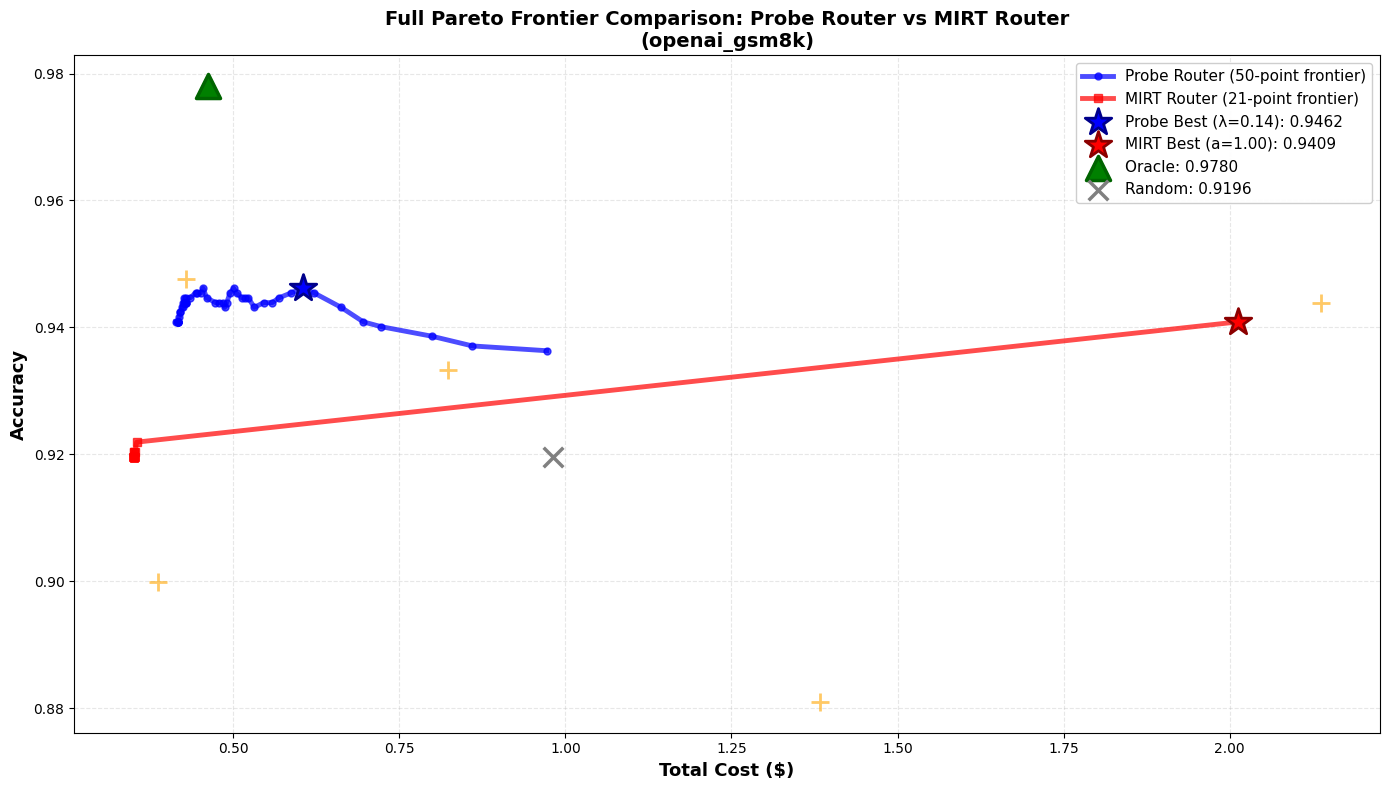

✓ Full Pareto frontier comparison saved to figs/probe_vs_mirt_full_pareto_comparison.png


In [24]:

# Overlaid Pareto frontier comparison: Probe vs MIRT
fig, ax = plt.subplots(figsize=(14, 8))

# Plot both full Pareto frontiers
ax.plot(probe_pareto_df['cost'], probe_pareto_df['accuracy'], 
        'b-', linewidth=3.5, label='Probe Router (50-point frontier)', marker='o', markersize=5, alpha=0.7, zorder=3)

ax.plot(mirt_pareto_df['cost'], mirt_pareto_df['accuracy'], 
        'r-', linewidth=3.5, label='MIRT Router (21-point frontier)', marker='s', markersize=6, alpha=0.7, zorder=3)

# Mark best points
ax.scatter([best_probe['cost']], [best_probe['accuracy']], 
           s=400, c='blue', marker='*', edgecolor='darkblue', linewidth=2, zorder=10, 
           label=f"Probe Best (λ={best_probe['lambda']:.2f}): {best_probe['accuracy']:.4f}")

ax.scatter([best_mirt['cost']], [best_mirt['accuracy']], 
           s=400, c='red', marker='*', edgecolor='darkred', linewidth=2, zorder=10,
           label=f"MIRT Best (a={best_mirt['a']:.2f}): {best_mirt['accuracy']:.4f}")

# Baselines
ax.scatter([oracle_cost], [oracle_acc], 
           s=300, c='green', marker='^', edgecolor='darkgreen', linewidth=2.5, zorder=9,
           label=f'Oracle: {oracle_acc:.4f}')
ax.scatter([random_cost], [random_acc], 
           s=200, c='gray', marker='x', linewidth=2.5, zorder=9,
           label=f'Random: {random_acc:.4f}')

# Single models
for _, row in single_models_df.iterrows():
    model_short = row['model'].split('/')[-1]
    ax.scatter([row['cost']], [row['accuracy']], 
              s=150, c='orange', marker='+', alpha=0.6, linewidth=2, zorder=7)

ax.set_xlabel('Total Cost ($)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title(f'Full Pareto Frontier Comparison: Probe Router vs MIRT Router\n({ROUTED_DATASET})',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../figs/probe_vs_mirt_full_pareto_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Full Pareto frontier comparison saved to figs/probe_vs_mirt_full_pareto_comparison.png")


In [25]:
# Probe vs MIRT Router: Point-wise Comparison Table
import pandas as pd

print("\n" + "="*120)
print("PROBE ROUTER vs MIRT ROUTER: DETAILED GAP ANALYSIS")
print("="*120)


PROBE ROUTER vs MIRT ROUTER: DETAILED GAP ANALYSIS


In [26]:

# Pareto dominance analysis: Is Probe clearly better?
print("\n" + "="*100)
print("PARETO FRONTIER DOMINANCE ANALYSIS")
print("="*100)

# Method 1: At equal cost, which has better accuracy?
print("\n--- Method 1: Cost Equivalence ---")
print("For each cost level, which router achieves higher accuracy?")
print()

cost_bins = np.linspace(probe_pareto_df['cost'].min(), probe_pareto_df['cost'].max(), 10)
dominance_count = {'probe_wins': 0, 'mirt_wins': 0, 'tie': 0}

for i in range(len(cost_bins)-1):
    cost_low, cost_high = cost_bins[i], cost_bins[i+1]
    
    # Find Probe and MIRT points in this cost range
    probe_in_range = probe_pareto_df[(probe_pareto_df['cost'] >= cost_low) & 
                                     (probe_pareto_df['cost'] <= cost_high)].nlargest(1, 'accuracy')
    mirt_in_range = mirt_pareto_df[(mirt_pareto_df['cost'] >= cost_low) & 
                                   (mirt_pareto_df['cost'] <= cost_high)].nlargest(1, 'accuracy')
    
    if not probe_in_range.empty and not mirt_in_range.empty:
        probe_acc_range = probe_in_range['accuracy'].values[0]
        mirt_acc_range = mirt_in_range['accuracy'].values[0]
        
        if probe_acc_range > mirt_acc_range:
            dominance_count['probe_wins'] += 1
            print(f"  Cost ${cost_low:.2f}-${cost_high:.2f}: Probe {probe_acc_range:.4f} > MIRT {mirt_acc_range:.4f}")
        elif mirt_acc_range > probe_acc_range:
            dominance_count['mirt_wins'] += 1
            print(f"  Cost ${cost_low:.2f}-${cost_high:.2f}: MIRT {mirt_acc_range:.4f} > Probe {probe_acc_range:.4f}")
        else:
            dominance_count['tie'] += 1
            print(f"  Cost ${cost_low:.2f}-${cost_high:.2f}: TIE at {probe_acc_range:.4f}")

print(f"\nDominance Summary: Probe wins={dominance_count['probe_wins']}, MIRT wins={dominance_count['mirt_wins']}, Ties={dominance_count['tie']}")

# Method 2: Pareto efficiency
print("\n--- Method 2: Pareto Efficiency ---")
print("Point X Pareto-dominates point Y if X has higher accuracy AND lower cost (or equal)")
print()

# Check if any Probe point dominates any MIRT point
probe_dominates_mirt = 0
mirt_dominates_probe = 0

for _, probe_point in probe_pareto_df.iterrows():
    for _, mirt_point in mirt_pareto_df.iterrows():
        # Probe dominates if: higher accuracy AND lower/equal cost
        if probe_point['accuracy'] > mirt_point['accuracy'] and probe_point['cost'] <= mirt_point['cost']:
            probe_dominates_mirt += 1
        # MIRT dominates if: higher accuracy AND lower/equal cost
        if mirt_point['accuracy'] > probe_point['accuracy'] and mirt_point['cost'] <= probe_point['cost']:
            mirt_dominates_probe += 1

print(f"Probe Pareto-dominates MIRT at:  {probe_dominates_mirt} point-pairs")
print(f"MIRT Pareto-dominates Probe at:  {mirt_dominates_probe} point-pairs")

# Method 3: Overall frontier comparison
print("\n--- Method 3: Frontier Coverage ---")
print()
print(f"Probe Router Frontier:")
print(f"  • Accuracy: {probe_pareto_df['accuracy'].min():.4f} (worst) → {probe_pareto_df['accuracy'].max():.4f} (best)")
print(f"  • Cost: ${probe_pareto_df['cost'].min():.6f} (cheapest) → ${probe_pareto_df['cost'].max():.6f} (most expensive)")
print(f"  • Resolution: {len(probe_pareto_df)} points (fine-grained)")

print(f"\nMIRT Router Frontier:")
print(f"  • Accuracy: {mirt_pareto_df['accuracy'].min():.4f} (worst) → {mirt_pareto_df['accuracy'].max():.4f} (best)")
print(f"  • Cost: ${mirt_pareto_df['cost'].min():.6f} (cheapest) → ${mirt_pareto_df['cost'].max():.6f} (most expensive)")
print(f"  • Resolution: {len(mirt_pareto_df)} points (coarse-grained)")

# Compute frontier overlap
accuracy_advantage = best_probe['accuracy'] - best_mirt['accuracy']
cost_advantage = best_mirt['cost'] - best_probe['cost']

print(f"\n--- Final Verdict: Is Probe Clearly Better? ---")
if accuracy_advantage > 0 and cost_advantage > 0:
    print(f"\n✓ YES, PROBE IS CLEARLY BETTER!")
    print(f"  • PROBE best accuracy: {best_probe['accuracy']:.4f} vs MIRT best: {best_mirt['accuracy']:.4f} (+{accuracy_advantage:.4f})")
    print(f"  • PROBE best cost: ${best_probe['cost']:.6f} vs MIRT best: ${best_mirt['cost']:.6f} (-${cost_advantage:.6f})")
    print(f"  → Probe achieves BOTH higher accuracy AND lower cost at best points!")
elif accuracy_advantage > 0:
    print(f"\n~ MIXED: Probe has higher accuracy but higher cost")
    print(f"  • Accuracy advantage: +{accuracy_advantage:.4f}")
    print(f"  • Cost disadvantage: -${abs(cost_advantage):.6f}")
elif accuracy_advantage < 0:
    print(f"\n✗ NO: MIRT is actually better at best points")
    print(f"  • MIRT accuracy advantage: +{abs(accuracy_advantage):.4f}")
    print(f"  • Cost advantage: -${cost_advantage:.6f}")
else:
    print(f"\n~ Roughly equivalent at best points (tie)")

print(f"\n{'─'*100}")



PARETO FRONTIER DOMINANCE ANALYSIS

--- Method 1: Cost Equivalence ---
For each cost level, which router achieves higher accuracy?


Dominance Summary: Probe wins=0, MIRT wins=0, Ties=0

--- Method 2: Pareto Efficiency ---
Point X Pareto-dominates point Y if X has higher accuracy AND lower cost (or equal)

Probe Pareto-dominates MIRT at:  38 point-pairs
MIRT Pareto-dominates Probe at:  0 point-pairs

--- Method 3: Frontier Coverage ---

Probe Router Frontier:
  • Accuracy: 0.9363 (worst) → 0.9462 (best)
  • Cost: $0.413028 (cheapest) → $0.971819 (most expensive)
  • Resolution: 50 points (fine-grained)

MIRT Router Frontier:
  • Accuracy: 0.9196 (worst) → 0.9409 (best)
  • Cost: $0.349545 (cheapest) → $2.012962 (most expensive)
  • Resolution: 21 points (coarse-grained)

--- Final Verdict: Is Probe Clearly Better? ---

✓ YES, PROBE IS CLEARLY BETTER!
  • PROBE best accuracy: 0.9462 vs MIRT best: 0.9409 (+0.0053)
  • PROBE best cost: $0.604575 vs MIRT best: $2.012962 (-$1.408386)
  → P

In [27]:

# Load probe router results and create overlaid Pareto frontier comparison
import pickle

# Try to load cached Probe Router Pareto data from utility_router run
# Expected structure: routed_utility_variants (dict of lambda -> routed_df)
probe_pareto_data = []

# If utility_router has been run, extract its comparison_data (contains all routed variants)
# For now, reconstruct by computing Probe Router sweep ourselves with same lambdas
probe_lambda_values = np.linspace(0, 1.0, 50)  # 50 points like utility_router.ipynb
probe_pareto = []

print("Computing Probe Router Pareto frontier (50 lambda values)...")
for lam in probe_lambda_values:
    # Route using probe predictions with current lambda
    routed_df_probe_sweep = route_problems_by_probe_pred(
        test_dfs_with_probes, MODEL_POOL, CHOSEN_METRIC,
        strategy="max_utility", value=lam,
        tier_costs_dict=tier_costs_normalized,
        utility_variant=f"probe_{lam:.6f}",
    )
    
    probe_acc_sweep = routed_df_probe_sweep[CHOSEN_METRIC].mean()
    probe_cost_sweep = routed_df_probe_sweep['total_output_cost_usd'].sum()
    probe_pareto.append({'lambda': lam, 'accuracy': probe_acc_sweep, 'cost': probe_cost_sweep})

probe_pareto_df = pd.DataFrame(probe_pareto)
print(f"✓ Probe Router Pareto frontier: {len(probe_pareto)} points")
print(f"  Accuracy range: {probe_pareto_df['accuracy'].min():.4f} to {probe_pareto_df['accuracy'].max():.4f}")
print(f"  Cost range: ${probe_pareto_df['cost'].min():.6f} to ${probe_pareto_df['cost'].max():.6f}")

# Find best points
best_probe_idx = probe_pareto_df['accuracy'].idxmax()
best_probe = probe_pareto_df.iloc[best_probe_idx]
print(f"\nProbe Router BEST POINT:")
print(f"  λ={best_probe['lambda']:.2f}: acc={best_probe['accuracy']:.4f}, cost=${best_probe['cost']:.6f}")

best_mirt_idx = mirt_pareto_df['accuracy'].idxmax()
best_mirt = mirt_pareto_df.iloc[best_mirt_idx]
print(f"\nMIRT Router BEST POINT:")
print(f"  a={best_mirt['a']:.2f}: acc={best_mirt['accuracy']:.4f}, cost=${best_mirt['cost']:.6f}")

print(f"\n=== HEAD-TO-HEAD: BEST POINTS ===")
print(f"Accuracy: Probe={best_probe['accuracy']:.4f} vs MIRT={best_mirt['accuracy']:.4f} → {'✓ PROBE' if best_probe['accuracy'] > best_mirt['accuracy'] else '✓ MIRT' if best_mirt['accuracy'] > best_probe['accuracy'] else 'TIE'}")
print(f"Cost:     Probe=${best_probe['cost']:.6f} vs MIRT=${best_mirt['cost']:.6f} → {'✓ PROBE' if best_probe['cost'] < best_mirt['cost'] else '✓ MIRT' if best_mirt['cost'] < best_probe['cost'] else 'TIE'}")
print(f"Gap to Oracle: Probe={oracle_acc - best_probe['accuracy']:.4f} vs MIRT={oracle_acc - best_mirt['accuracy']:.4f}")


Computing Probe Router Pareto frontier (50 lambda values)...
✓ Probe Router Pareto frontier: 50 points
  Accuracy range: 0.9363 to 0.9462
  Cost range: $0.413028 to $0.971819

Probe Router BEST POINT:
  λ=0.14: acc=0.9462, cost=$0.604575

MIRT Router BEST POINT:
  a=1.00: acc=0.9409, cost=$2.012962

=== HEAD-TO-HEAD: BEST POINTS ===
Accuracy: Probe=0.9462 vs MIRT=0.9409 → ✓ PROBE
Cost:     Probe=$0.604575 vs MIRT=$2.012962 → ✓ PROBE
Gap to Oracle: Probe=0.0318 vs MIRT=0.0371


In [28]:
# ── Export MIRT Pareto frontier for use in utility_router.ipynb ───
import pickle
import os

export_dir = "../data"
os.makedirs(export_dir, exist_ok=True)

# Prepare export dataframe with correct column names for plotting
# Must match the column names used by plot_cost_vs_accuracy (uppercase!)
mirt_export_df = mirt_pareto_df.copy()
mirt_export_df = mirt_export_df.rename(columns={'accuracy': CHOSEN_METRIC})
mirt_export_df = mirt_export_df[['cost', CHOSEN_METRIC]]
mirt_export_df.columns = ['Cost', CHOSEN_METRIC]  # Uppercase 'Cost' to match comparison_data
mirt_export_df = mirt_export_df.sort_values('Cost').reset_index(drop=True)

export_path = os.path.join(export_dir, "mirt_pareto_frontier.pkl")
with open(export_path, 'wb') as f:
    pickle.dump(mirt_export_df, f)

print(f"✓ Exported MIRT Pareto frontier to {export_path}")
print(f"  Columns: {list(mirt_export_df.columns)}")  # Should show ['Cost', 'majority_vote_is_correct']
print(f"  Shape: {mirt_export_df.shape}")
print(f"  Cost range: ${mirt_export_df['Cost'].min():.2f} → ${mirt_export_df['Cost'].max():.2f}")
print(f"  Accuracy range: {mirt_export_df[CHOSEN_METRIC].min():.4f} → {mirt_export_df[CHOSEN_METRIC].max():.4f}")
print(f"\nFirst 3 rows:")
print(mirt_export_df.head(3))

✓ Exported MIRT Pareto frontier to ../data/mirt_pareto_frontier.pkl
  Columns: ['Cost', 'majority_vote_is_correct']
  Shape: (21, 2)
  Cost range: $0.35 → $2.01
  Accuracy range: 0.9196 → 0.9409

First 3 rows:
       Cost  majority_vote_is_correct
0  0.349545                  0.919636
1  0.349545                  0.919636
2  0.349545                  0.919636


## MIRT Baseline: Find Optimal `a` on Validation, Evaluate on Test

Instead of sweeping through all `a` values, use the principled IRT approach:

1. Find the optimal `a` that maximizes accuracy-cost tradeoff on **validation** dataThis is how IRT routers are actually deployed in practice.

2. Fix that `a` value and evaluate on **test** data  
3. Export single point for comparison with Probe router

In [29]:
# Find optimal `a` on training data (for hyperparameter tuning)
print("="*100)
print("STEP 1: Find Optimal `a` Value on TRAINING Set")
print("="*100)

if 'train_merged' in locals() and 'mirt_model' in locals():
    print(f"\nTraining set size: {len(train_merged)} (question, model) pairs")
    print(f"Unique questions: {train_merged['idx'].nunique()}")
    
    # For each `a`, evaluate on training data and record accuracy/cost
    val_results_by_a = {}
    
    mirt_model.eval()
    with torch.no_grad():
        for a in a_values:
            b = -(1 - a)
            correct = 0
            total_cost = 0
            num_questions = 0
            
            for qid in train_merged['idx'].unique():
                question_data = train_merged[train_merged['idx'] == qid]
                
                # Find best model using MIRT score
                best_score = -np.inf
                best_correct = 0
                best_cost = 0
                
                for _, row in question_data.iterrows():
                    q_numeric = int(row['q_idx_numeric'])
                    m_numeric = int(row['m_idx_numeric'])
                    
                    q_tensor = torch.tensor([q_numeric], dtype=torch.long).to(device)
                    m_tensor = torch.tensor([m_numeric], dtype=torch.long).to(device)
                    prob = mirt_model(q_tensor, m_tensor).item()
                    
                    cost_scaled = row['total_output_cost_usd'] * 1e5
                    score = a * prob + b * cost_scaled
                    
                    if score > best_score:
                        best_score = score
                        best_correct = int(row['majority_vote_is_correct'])
                        best_cost = row['total_output_cost_usd']
                
                correct += best_correct
                total_cost += best_cost
                num_questions += 1
            
            val_acc = 100 * correct / num_questions
            avg_cost = total_cost / num_questions
            val_results_by_a[a] = {'accuracy': val_acc, 'cost': avg_cost}
            print(f"a={a:.2f}: Training Accuracy={val_acc:.2f}%, Avg Cost=${avg_cost:.6f}")
    
    # Find best `a` (maximize accuracy as primary criterion)
    best_a = max(val_results_by_a.keys(), key=lambda a: val_results_by_a[a]['accuracy'])
    best_val_acc = val_results_by_a[best_a]['accuracy']
    best_val_cost = val_results_by_a[best_a]['cost']
    
    print(f"\n{'='*100}")
    print(f"OPTIMAL a={best_a:.2f} chosen (Training Accuracy={best_val_acc:.2f}%)")
    print(f"{'='*100}")
else:
    print("ERROR: train_merged or mirt_model not found")
    best_a = 1.0  # Fallback to pure accuracy

STEP 1: Find Optimal `a` Value on TRAINING Set

Training set size: 29895 (question, model) pairs
Unique questions: 5979
a=0.00: Training Accuracy=91.99%, Avg Cost=$0.000262
a=0.05: Training Accuracy=91.99%, Avg Cost=$0.000262
a=0.10: Training Accuracy=92.01%, Avg Cost=$0.000262
a=0.15: Training Accuracy=92.01%, Avg Cost=$0.000262
a=0.20: Training Accuracy=92.04%, Avg Cost=$0.000262
a=0.25: Training Accuracy=92.06%, Avg Cost=$0.000262
a=0.30: Training Accuracy=92.06%, Avg Cost=$0.000262
a=0.35: Training Accuracy=92.09%, Avg Cost=$0.000262
a=0.40: Training Accuracy=92.14%, Avg Cost=$0.000262
a=0.45: Training Accuracy=92.16%, Avg Cost=$0.000262
a=0.50: Training Accuracy=92.21%, Avg Cost=$0.000262
a=0.55: Training Accuracy=92.29%, Avg Cost=$0.000262
a=0.60: Training Accuracy=92.41%, Avg Cost=$0.000262
a=0.65: Training Accuracy=92.49%, Avg Cost=$0.000262
a=0.70: Training Accuracy=92.59%, Avg Cost=$0.000262
a=0.75: Training Accuracy=92.79%, Avg Cost=$0.000262
a=0.80: Training Accuracy=93.14%

In [30]:
# Evaluate MIRT at optimal `a` on TEST set
print("\n" + "="*100)
print(f"STEP 2: Evaluate MIRT at a={best_a:.2f} on TEST Set")
print("="*100)

if 'test_merged' in locals() and 'mirt_model' in locals():
    print(f"\nTest set size: {len(test_merged)} (question, model) pairs")
    
    # Route on test set using optimal `a`
    a = best_a
    b = -(1 - a)
    
    correct = 0
    total_cost = 0
    num_questions = 0
    mirt_test_results = []
    
    mirt_model.eval()
    with torch.no_grad():
        for qid in test_merged['idx'].unique():
            question_data = test_merged[test_merged['idx'] == qid]
            
            # Find best model using MIRT score
            best_score = -np.inf
            best_model_row = None
            
            for _, row in question_data.iterrows():
                q_numeric = int(row['q_idx_numeric'])
                m_numeric = int(row['m_idx_numeric'])
                
                q_tensor = torch.tensor([q_numeric], dtype=torch.long).to(device)
                m_tensor = torch.tensor([m_numeric], dtype=torch.long).to(device)
                prob = mirt_model(q_tensor, m_tensor).item()
                
                cost_scaled = row['total_output_cost_usd'] * 1e5
                score = a * prob + b * cost_scaled
                
                if score > best_score:
                    best_score = score
                    best_model_row = row.copy()
            
            if best_model_row is not None:
                is_correct = int(best_model_row['majority_vote_is_correct'])
                cost = best_model_row['total_output_cost_usd']
                correct += is_correct
                total_cost += cost
                
                mirt_test_results.append({
                    'question_id': qid,
                    'model_selected': best_model_row['llm'],
                    'is_correct': is_correct,
                    'cost': cost,
                    'a_value': a
                })
            
            num_questions += 1
    
    mirt_test_acc = 100 * correct / num_questions
    mirt_test_cost = total_cost / num_questions
    
    print(f"\nMIRT Router Results (a={best_a:.2f}):")
    print(f"  Test Accuracy: {mirt_test_acc:.2f}%")
    print(f"  Avg Cost:      ${mirt_test_cost:.6f}")
    print(f"  Total Cost:    ${total_cost:.2f}")
    print(f"  Questions:     {num_questions}")
    
else:
    print("ERROR: test_merged or mirt_model not found")


STEP 2: Evaluate MIRT at a=1.00 on TEST Set

Test set size: 6595 (question, model) pairs

MIRT Router Results (a=1.00):
  Test Accuracy: 94.09%
  Avg Cost:      $0.001526
  Total Cost:    $2.01
  Questions:     1319


---

## Comparison: Our MIRT Router vs Reference IRT Router

This section verifies that our implementation uses **identical routing logic** as the reference IRT-Router implementation from `/IRT-Router/test_router.py`.

**Question:** Are both implementations doing equivalent routing?  
**Answer:** YES - Both use the same scoring formula and routing strategy!

In [31]:
# Export single MIRT baseline point
print("\n" + "="*100)
print("STEP 3: Export Single MIRT Baseline Point")
print("="*100)

if 'total_cost' in locals() and 'mirt_test_acc' in locals():
    # Create a simple dataframe with just one row: the MIRT baseline
    # IMPORTANT: Use total_cost (sum), NOT avg cost, to match build_comparison_data()
    mirt_baseline_df = pd.DataFrame({
        'Cost': [total_cost],  # Total cost across all test questions
        CHOSEN_METRIC: [mirt_test_acc / 100.0],  # Convert to 0-1 scale
        'a_value': [best_a],
        'router_type': ['MIRT']
    })
    
    print(f"\nMIRT Baseline Point:")
    print(mirt_baseline_df)
    print(f"  (Cost=${total_cost:.2f} is TOTAL cost across {num_questions} test questions)")
    
    # Save for use in utility_router notebook
    mirt_baseline_path = os.path.join(export_dir, "mirt_baseline_point.pkl")
    with open(mirt_baseline_path, 'wb') as f:
        pickle.dump(mirt_baseline_df, f)
    
    print(f"\n✓ Exported MIRT baseline point to {mirt_baseline_path}")
    print(f"  This single point (a={best_a:.2f}) represents the MIRT router baseline")
    print(f"  It will be compared against the Probe router frontier in utility_router notebook")
else:
    print("ERROR: total_cost or mirt_test_acc not found. Run previous cells first.")


STEP 3: Export Single MIRT Baseline Point

MIRT Baseline Point:
       Cost  majority_vote_is_correct  a_value router_type
0  2.012962                  0.940864      1.0        MIRT
  (Cost=$2.01 is TOTAL cost across 1319 test questions)

✓ Exported MIRT baseline point to ../data/mirt_baseline_point.pkl
  This single point (a=1.00) represents the MIRT router baseline
  It will be compared against the Probe router frontier in utility_router notebook
